In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def get_stock_data(ticker, start):

    df = yf.download(
        ticker,
        start=start,
        actions=True,
        progress=False
    )
    df.columns = df.columns.get_level_values(0)
    df = df[['Close', 'Dividends']]
    df = df.rename(columns={
        'Close': f'{ticker}_close',
        'Dividends': f'{ticker}_dividends'
    })

    return df


tickers = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA', 'RENT3.SA', 'WEGE3.SA', 'MGLU3.SA',  'B3SA3.SA']
start_date = '2010-01-01'
dfs = [get_stock_data(ticker, start_date) for ticker in tickers]
df = pd.concat(dfs, axis=1)

df

Price,PETR4.SA_close,PETR4.SA_dividends,VALE3.SA_close,VALE3.SA_dividends,ITUB4.SA_close,ITUB4.SA_dividends,BBDC4.SA_close,BBDC4.SA_dividends,ABEV3.SA_close,ABEV3.SA_dividends,RENT3.SA_close,RENT3.SA_dividends,WEGE3.SA_close,WEGE3.SA_dividends,MGLU3.SA_close,MGLU3.SA_dividends,B3SA3.SA_close,B3SA3.SA_dividends
Date,,,,,,,,,,,,,,,,,,
2010-01-04,8.019320,0.0,20.094961,0.0,7.136031,0.076199,6.222201,0.00000,3.108145,0.0,3.974540,0.0,1.914479,0.0,NaN,NaN,7.116768,0.0
2010-01-05,7.950561,0.0,20.282290,0.0,7.182273,0.000000,6.191578,0.00516,3.126430,0.0,4.027535,0.0,1.910302,0.0,NaN,NaN,7.144243,0.0
2010-01-06,8.057996,0.0,20.711588,0.0,7.120022,0.000000,6.142045,0.00000,3.158324,0.0,4.341421,0.0,1.920747,0.0,NaN,NaN,7.413527,0.0
2010-01-07,7.982790,0.0,20.797451,0.0,7.047096,0.000000,6.125532,0.00000,3.173153,0.0,4.157981,0.0,1.953125,0.0,NaN,NaN,7.589387,0.0
2010-01-08,7.939814,0.0,21.000385,0.0,6.940377,0.000000,6.118926,0.00000,3.167059,0.0,4.196707,0.0,2.024148,0.0,NaN,NaN,7.413527,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-06,47.270000,0.0,81.230003,0.0,41.779999,0.000000,19.270000,0.00000,16.950001,0.0,47.650002,0.0,44.939999,0.0,8.03,0.0,18.360001,0.0
2026-05-07,46.220001,0.0,80.070000,0.0,40.790001,0.000000,18.520000,0.00000,16.410000,0.0,46.349998,0.0,44.310001,0.0,7.94,0.0,17.780001,0.0
2026-05-08,45.669998,0.0,80.800003,0.0,41.259998,0.000000,18.590000,0.00000,16.320000,0.0,49.880001,0.0,45.520000,0.0,7.15,0.0,17.930000,0.0


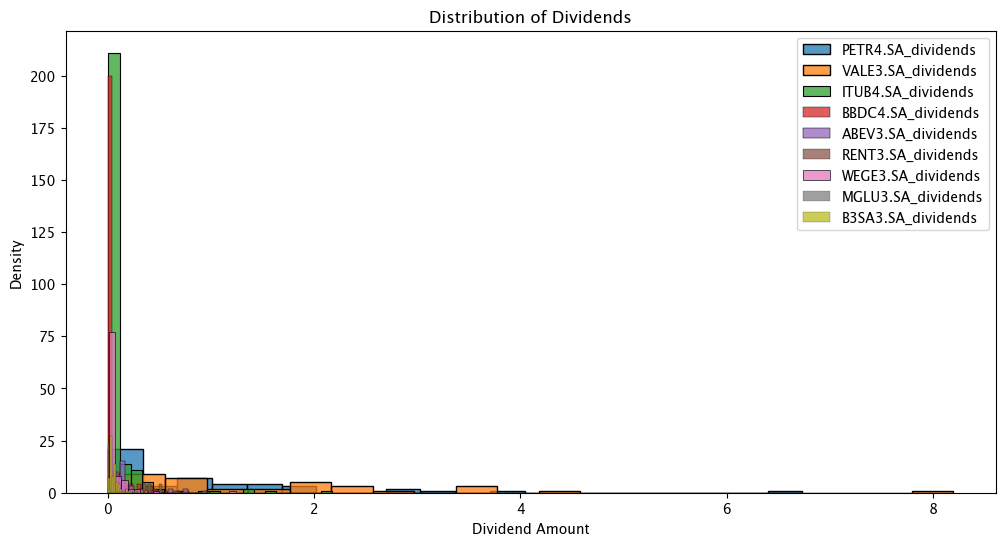

In [72]:
def distribution_returns(df):

    dividends_cols = [
        col for col in df.columns
        if col.endswith('_dividends')
    ]

    # cria UMA figura
    plt.figure(figsize=(12, 6))

    for col in dividends_cols:

        dividends = (
            df[col]
            [df[col] > 0]
            .dropna()
        )

        if len(dividends) > 0:

            sns.histplot(
                dividends,
                label=col,
                bins=20
            )

    plt.title('Distribution of Dividends')
    plt.xlabel('Dividend Amount')
    plt.ylabel('Density')

    plt.legend()

    plt.show()


distribution_returns(df)

In [73]:
df[df['PETR4.SA_dividends'] > 0]['PETR4.SA_dividends'].describe()

count    47.000000
mean      0.979903
std       1.250739
min       0.000461
25%       0.200000
50%       0.671924
75%       1.253458
max       6.732003
Name: PETR4.SA_dividends, dtype: float64

In [24]:
ticker = ['^VIX', 'GC=F', 'BTC-USD']

df = yf.download(
    ticker,
    start='2010-01-01',
    end='2025-12-31',
)['Close']

df = df.dropna()
df.to_csv('study_statistics.csv')

[*********************100%***********************]  3 of 3 completed


[Price       ^VIX_close  ^VIX_dividends
 Date                                  
 2010-01-04   20.040001             0.0
 2010-01-05   19.350000             0.0
 2010-01-06   19.160000             0.0
 2010-01-07   19.059999             0.0
 2010-01-08   18.129999             0.0
 ...                ...             ...
 2026-05-06   17.389999             0.0
 2026-05-07   17.080000             0.0
 2026-05-08   17.190001             0.0
 2026-05-11   18.379999             0.0
 2026-05-12   17.990000             0.0
 
 [4114 rows x 2 columns],
 Price        GC=F_close  GC=F_dividends
 Date                                   
 2010-01-04  1117.699951             0.0
 2010-01-05  1118.099976             0.0
 2010-01-06  1135.900024             0.0
 2010-01-07  1133.099976             0.0
 2010-01-08  1138.199951             0.0
 ...                 ...             ...
 2026-05-06  4681.899902             0.0
 2026-05-07  4699.799805             0.0
 2026-05-08  4720.399902             0.0
 